# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
# importa las librerías

from matplotlib.image import imread
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee las imagenes
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
# usa imread

image = imread("ladybug.png")

# comprueba las dimensiones del numpy array

image.shape

(533, 800, 3)

Muestra la imagen para ver que se ha cargado bien

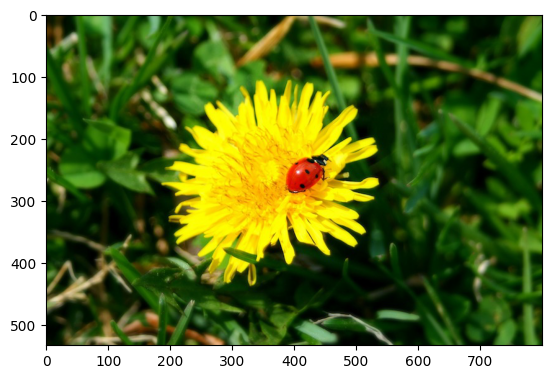

In [3]:
# usa imshow para mostrar la imagen

plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [10]:
# modifica las dimensiones del numpy array


X = image.reshape(-2,3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [13]:

# kmeans con 8 centroides por ejemplo, semilla 42 y 10 repeticiones del kmeans para elegir los centroides que acaban con la mejor inercia

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X)


# ajústalo a tus datos

X
kmeans.predict(X)

array([5, 5, 5, ..., 0, 5, 5], shape=(426400,), dtype=int32)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizas para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [14]:

# usa las etiquetas a los centroides para segmentar la imagen original

X_segmentada = kmeans.cluster_centers_[kmeans.labels_]
X_segmentada

array([[0.02266252, 0.11037236, 0.00577379],
       [0.02266252, 0.11037236, 0.00577379],
       [0.02266252, 0.11037236, 0.00577379],
       ...,
       [0.09921834, 0.2531085 , 0.01676021],
       [0.02266252, 0.11037236, 0.00577379],
       [0.02266252, 0.11037236, 0.00577379]],
      shape=(426400, 3), dtype=float32)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [15]:

# hay que volver a hacer la imagen rectangular, no una ristra de píxeles

imagen_segmentada = X_segmentada.reshape(image.shape)
imagen_segmentada.shape

(533, 800, 3)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

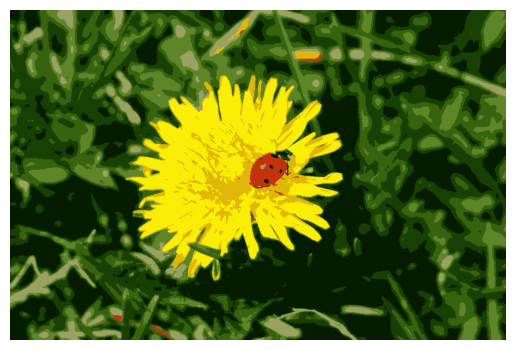

In [16]:
# muestra la imagen modificada

plt.imshow(imagen_segmentada)
plt.axis("off");

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [18]:
# crea una función que dada una imagen, una cantidad de colores y si se quiere guardar la imagen modificada o solo mostrarla, que siga esos pasos


def generar_imagen_segmentada(image, colores, guardar=True):

    X = image.reshape(-1, 3)

    modelo = KMeans(n_clusters=colores, random_state=42, n_init=10).fit(X)

    nueva_imagen = modelo.cluster_centers_[modelo.labels_]

    nueva_imagen = nueva_imagen.reshape(image.shape)

    plt.imshow(nueva_imagen)

    if guardar:
        plt.savefig("imagen_segmentada.jpg")